<center>

![](recursos/img/logoitqv1.jpg)

</center>

## PAO26-26-Python 1, Regresion Logistica

<center>

![](recursos/img/python_logo.png)

</center>

*Cynthia Cuñez*

 Repositorio: <a href="https://github.com/cynthia0206/machine12926nocturno/blob/main/PAO26-07-22-REGRESION-LOGISTICA.ipynb">Link del repositorio de Github</a>

 * https://github.com/cynthia0206/machine12926nocturno/blob/main/PAO26-07-22-REGRESION-LOGISTICA.ipynb

In [1]:
import sklearn.metrics as metrics
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score,train_test_split, KFold
from sklearn import preprocessing
from evaluacion_funciones import *


In [2]:
# Carga de datos.
datos = load_iris()
X = datos.data[:,2:] # Utilizamos solo 2 atributos.
y = datos.target
print(np.shape(X))


(150, 2)


In [3]:
# Métricas de evaluación.
metricas = {
'ACC': metrics.accuracy_score,
'PREC': lambda y_true, y_pred:
metrics.precision_score(y_true, y_pred, average='micro'),
'RECALL': lambda y_true, y_pred:
metrics.recall_score(y_true, y_pred, average='micro'),
'F1': lambda y_true, y_pred:
metrics.f1_score(y_true, y_pred, average='micro')}

In [6]:
# 1) Partición de datos externa
X_training, X_testing, y_training, y_testing = train_test_split(X, y,test_size=0.2, random_state=42)
print(np.shape(X_training))

(120, 2)


# ------------- TRAINING ---------------- #


 # 2) Extracción de características

In [7]:
# 3) Estandarización de los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
X_stdr = standardizer.fit_transform(X_training)
# print(X_stdr)

# 4) Selección de atributos

In [9]:
# 5) Construcción del algoritmo de aprendizaje.
algoritmos = {'LOGR': LogisticRegression(penalty='l1', solver='saga',max_iter=1000, random_state=42, multi_class='ovr')}

In [19]:
# 5.1) Validación cruzada interna y Optimización de los hiperparámetros
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_predict, KFold

# 5) Construcción del algoritmo de aprendizaje
algoritmos = {
    'LOGR': OneVsRestClassifier(
        LogisticRegression(
            penalty='l1',
            solver='saga',
            max_iter=1000,
            random_state=42
        )
    )
}

# 5.1) Validación cruzada interna y evaluación
y_pred = {}

for nombre, alg in algoritmos.items():
    y_pred[nombre] = cross_val_predict(
        alg,
        X_stdr,
        y_training,
        cv=KFold(n_splits=10, shuffle=True, random_state=42)
    )

    results = evaluacion(
        y_training,
        y_pred[nombre],
        metricas
    )

    print(metrics.confusion_matrix(y_training, y_pred[nombre]))
    print(results)

[[40  0  0]
 [ 1 37  3]
 [ 0  5 34]]
{'ACC': 0.925, 'PREC': 0.925, 'RECALL': 0.925, 'F1': 0.925}


C:\Users\cynth\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\cynth\Desktop\machinelearningnocturno\evaluacion_funciones.py:50: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, cmap=plt.cm.Paired,


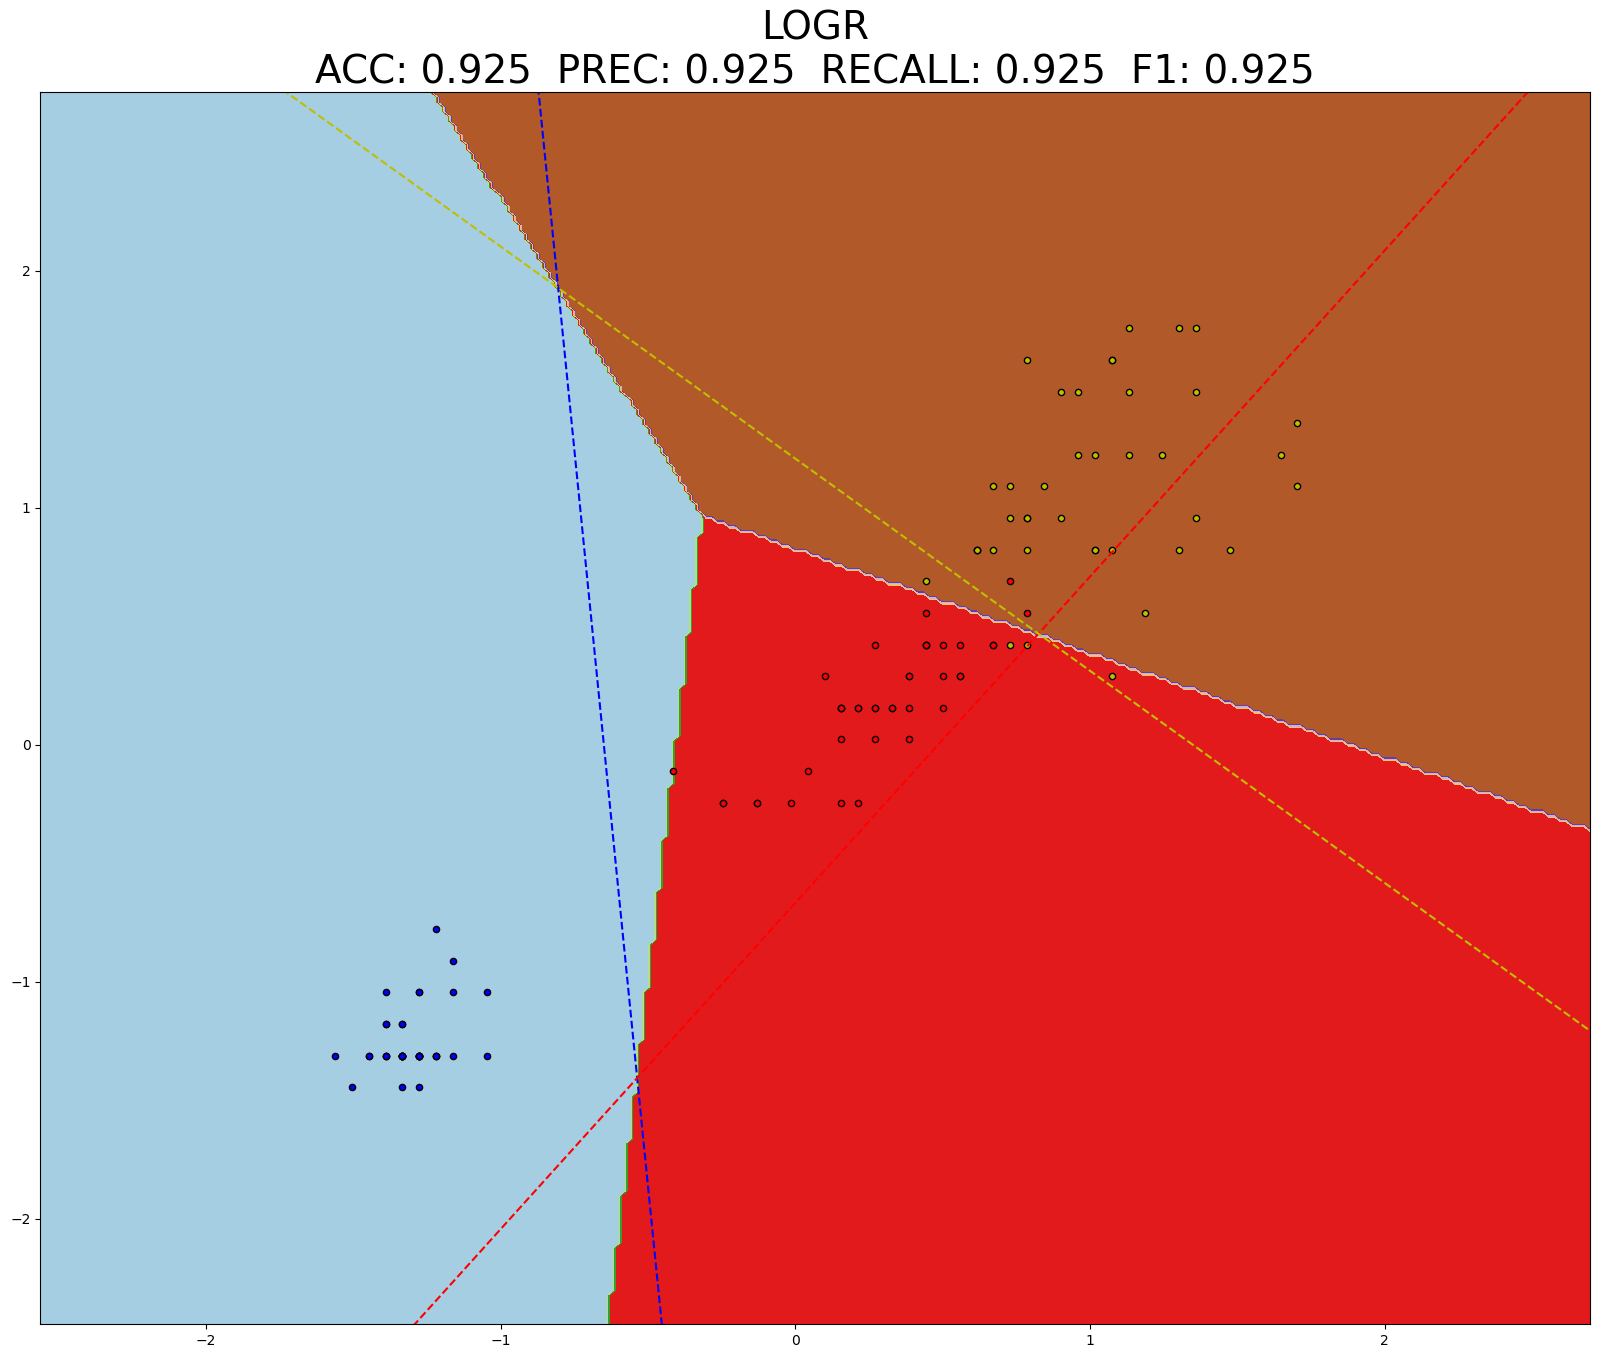

In [12]:
# 5.2) Entrenamiento del modelo definitivo
model = algoritmos['LOGR'].fit(X_stdr, y_training)
# Visualización de las fronteras de decisión
mapa_modelo_clasif_2d(X_stdr, y_training, model, results, nombre)

 # ------------- PREDICTION ---------------- #
# 6) Extracción de las características de test


In [20]:
 # 7) Estandarización de las característiacs de test
X_test_stdr = standardizer.transform(X_testing)

# 8) Selección de los atributos de test

In [21]:
# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_stdr)
print(y_pred_test)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [22]:
# 10) Evaluación del modelo sobre el conjunto de test
results = evaluacion(y_testing, y_pred_test, metricas)
print(results)
print(metrics.confusion_matrix(y_testing, y_pred_test))

{'ACC': 1.0, 'PREC': 1.0, 'RECALL': 1.0, 'F1': 1.0}
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


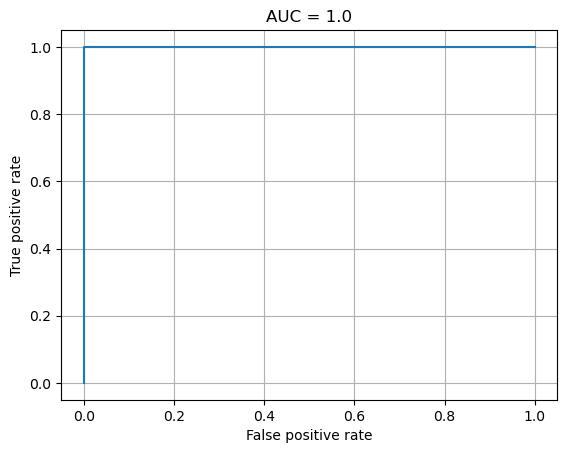

In [25]:
# Ploteamos la curva ROC
y_proba_test = model.predict_proba(X_test_stdr) # "predict_proba" para extraer␣probabilidades vez de predicciones
y_test_bin = preprocessing.label_binarize(y_testing, classes=[0,1,2]) # Usar␣"label_binarize" en el caso de problemas multiclase
auc = metrics.roc_auc_score(y_testing, y_proba_test, multi_class='ovr') # Area␣Under the ROC curve (AUC)
fpr, tpr, th = metrics.roc_curve(y_test_bin[:,1], y_proba_test[:,1])
plt.plot(fpr, tpr)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('AUC = ' + str(np.round(auc,4)))
plt.grid()
plt.show()
